# TensorDict Dataset Analysis

**WSmart+ Route — Data Analysis Notebook**

This notebook provides a thorough analysis of `.td` (TensorDict) problem-instance datasets used for training and evaluating routing agents. It covers:

1. **Loading & inspecting** a TensorDict dataset (shapes, dtypes, memory)
2. **Tensor statistics** — per-key summary with mean / std / min / max
3. **Coordinate & spatial analysis** — node layouts, depot positions, nearest-neighbour distances
4. **Waste distributions** — histograms, box plots, CDFs
5. **Batch-level statistics** — per-instance aggregates and their spread
6. **Multi-dataset comparison** — different problem sizes side-by-side
7. **DataLoader integration** — `TensorDictDataset` and `DataLoader` walkthrough

**Prerequisites**: A working WSmart+ Route installation (`uv sync` from project root).

---
## 0. Environment Setup

In [144]:
from notebook_setup import setup_google_colab, setup_home_directory

NOTEBOOK_NAME = "data_analysis"
PROJECT_ROOT = setup_home_directory(NOTEBOOK_NAME)
IN_COLAB, gdrive, gfiles = setup_google_colab(NOTEBOOK_NAME)

Already added home_dir to system path: /home/pkhunter/Repositories/WSmart-Route


In [145]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from torch.utils.data import DataLoader
from tensordict import TensorDict

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
CMAP = "viridis"

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")

PyTorch : 2.2.2+cu121
Device  : cuda


---
## 1. Loading & Inspecting a TensorDict Dataset

`.td` files are plain `torch.save` checkpoints of a `TensorDict`.  
Set `DATASET_PATH` to any `.td` file under `data/datasets/`.

In [146]:
# ── Configure dataset path ────────────────────────────────────────────────────
N_DAYS = 31
GRAPH_SIZE = 50
DATASET_NAME = "wsr"
PROBLEM_NAME = "vrpp"
DATA_DISTRIBUTION = "gamma1"
DATASET_PATH = os.path.join(
    PROJECT_ROOT,
    "data", "datasets", PROBLEM_NAME,
    f"{PROBLEM_NAME}{GRAPH_SIZE}_{DATA_DISTRIBUTION}_{DATASET_NAME}{N_DAYS}_seed{SEED}.td",
)

# ── Load ──────────────────────────────────────────────────────────────────────
td: TensorDict = torch.load(DATASET_PATH, map_location="cpu", weights_only=False)

print(f"File : {os.path.basename(DATASET_PATH)}")
print(f"Size : {os.path.getsize(DATASET_PATH) / 1e6:.1f} MB")
print(f"Type : {type(td).__name__}")
print(f"\nBatch size : {td.batch_size}")
print(f"Keys       : {list(td.keys())}")

File : vrpp50_gamma1_wsr31_seed42.td
Size : 78.9 MB
Type : TensorDict

Batch size : torch.Size([128000])
Keys       : ['depot', 'locs', 'waste', 'capacity', 'max_waste']


In [147]:

# ── Tensor inventory ──────────────────────────────────────────────────────────
rows = []
for key in td.keys():
    t = td[key]
    rows.append({
        "Key"   : key,
        "Shape" : tuple(t.shape),
        "Dtype" : str(t.dtype).replace("torch.", ""),
        "Min"   : float(t.min()),
        "Max"   : float(t.max()),
        "Mean"  : float(t.float().mean()),
        "Std"   : float(t.float().std()),
        "MB"    : t.element_size() * t.numel() / 1e6,
    })

inv = pd.DataFrame(rows).set_index("Key")
inv["MB"] = inv["MB"].map("{:.2f}".format)
inv[["Min", "Max", "Mean", "Std"]] = inv[["Min", "Max", "Mean", "Std"]].map("{:.4f}".format)
display(inv)


,Shape,Dtype,Min,Max,Mean,Std,MB
Key,,,,,,,
depot,"(128000, 2)",float32,0.0000,0.0000,0.0000,0.0000,1.02
locs,"(128000, 50, 2)",float32,0.2998,1.0000,0.6299,0.1410,51.20
waste,"(128000, 50)",float32,0.0044,1.0000,0.2550,0.1672,25.60
capacity,"(128000,)",float32,100.0000,100.0000,100.0000,0.0000,0.51
max_waste,"(128000,)",float32,1.0000,1.0000,1.0000,0.0000,0.51


In [148]:

# ── Convenience aliases ───────────────────────────────────────────────────────
BATCH_SIZE = td.batch_size[0]
locs       = td["locs"].numpy()   # (B, N, 2)
depot      = td["depot"].numpy()  # (B, 2)
B, N, _    = locs.shape

# Gather node-level scalar tensors.
# Time-series tensors (B, T, N) are reduced to (B, N) by averaging over T.
NODE_SCALARS = {}
for k in ("waste"):
    if k not in td.keys():
        continue
    arr = td[k].numpy()
    if arr.ndim == 2:          # (B, N) — standard per-node scalar
        NODE_SCALARS[k] = arr
    elif arr.ndim == 3:        # (B, T, N) — time-series; collapse with mean
        NODE_SCALARS[k] = arr.mean(axis=1)
        print(f"  Note: '{k}' is time-series shaped {arr.shape} → averaged to {NODE_SCALARS[k].shape}")

INST_SCALARS = {
    k: td[k].numpy()
    for k in ("capacity", "max_waste", "max_length")
    if k in td.keys()
}

print(f"Batch size    : {B}")
print(f"Nodes per inst: {N}")
print(f"Node scalars  : {list(NODE_SCALARS)}")
print(f"Inst scalars  : {list(INST_SCALARS)}")


Batch size    : 128000
Nodes per inst: 50
Node scalars  : []
Inst scalars  : ['capacity', 'max_waste']


---
## 2. Coordinate & Spatial Analysis

### 2.1 — Individual Instance Visualisation

In [149]:
from typing import Optional


# ── Helper: reduce any tensor slice to a 1-D (N,) node array ─────────────────
def _node_scalar(arr: np.ndarray, i: int) -> np.ndarray:
    """Return shape (N,) from arr[i], averaging over any extra leading dims.

    Handles:
      (B, N)        → arr[i] is (N,)         – returned as-is
      (B, T, N)     → arr[i] is (T, N)        – averaged over T
      (B, T1, T2, N)→ arr[i] is (T1, T2, N)  – averaged over T1, T2
    """
    v = np.asarray(arr[i], dtype=float)
    while v.ndim > 1:
        v = v.mean(axis=0)
    return v


# ── Reusable single-instance scatter plot ────────────────────────────────────
def plot_instance(
    node_xy: np.ndarray,
    depot_xy: np.ndarray,
    color_values: Optional[np.ndarray] = None,
    color_label: str = "Value",
    title: str = "",
    ax: Optional["plt.Axes"] = None,
) -> "plt.Axes":
    """Scatter-plot one VRP instance.

    Parameters
    ----------
    node_xy:      (N, 2) node coordinates.
    depot_xy:     (2,) depot coordinate.
    color_values: scalar values for node colouring – any shape reducible to
                  (N,) is accepted; extra leading dims are averaged.
    """
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(5, 5))

    if color_values is not None:
        c = np.asarray(color_values, dtype=float)
        while c.ndim > 1:          # collapse time / extra dims → (N,)
            c = c.mean(axis=0)
        sc = ax.scatter(
            node_xy[:, 0], node_xy[:, 1],
            c=c, cmap=CMAP, vmin=float(c.min()), vmax=float(c.max()),
            s=70, edgecolors="white", linewidth=0.5, zorder=2,
        )
        plt.colorbar(sc, ax=ax, shrink=0.75, label=color_label, pad=0.02)
    else:
        ax.scatter(node_xy[:, 0], node_xy[:, 1],
                   s=70, alpha=0.7, edgecolors="white", linewidth=0.5, zorder=2)

    ax.scatter(depot_xy[0], depot_xy[1],
               c="red", s=250, marker="*",
               edgecolors="black", linewidth=0.8, zorder=3, label="Depot")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.8)
    if standalone:
        plt.tight_layout()
        plt.show()
    return ax

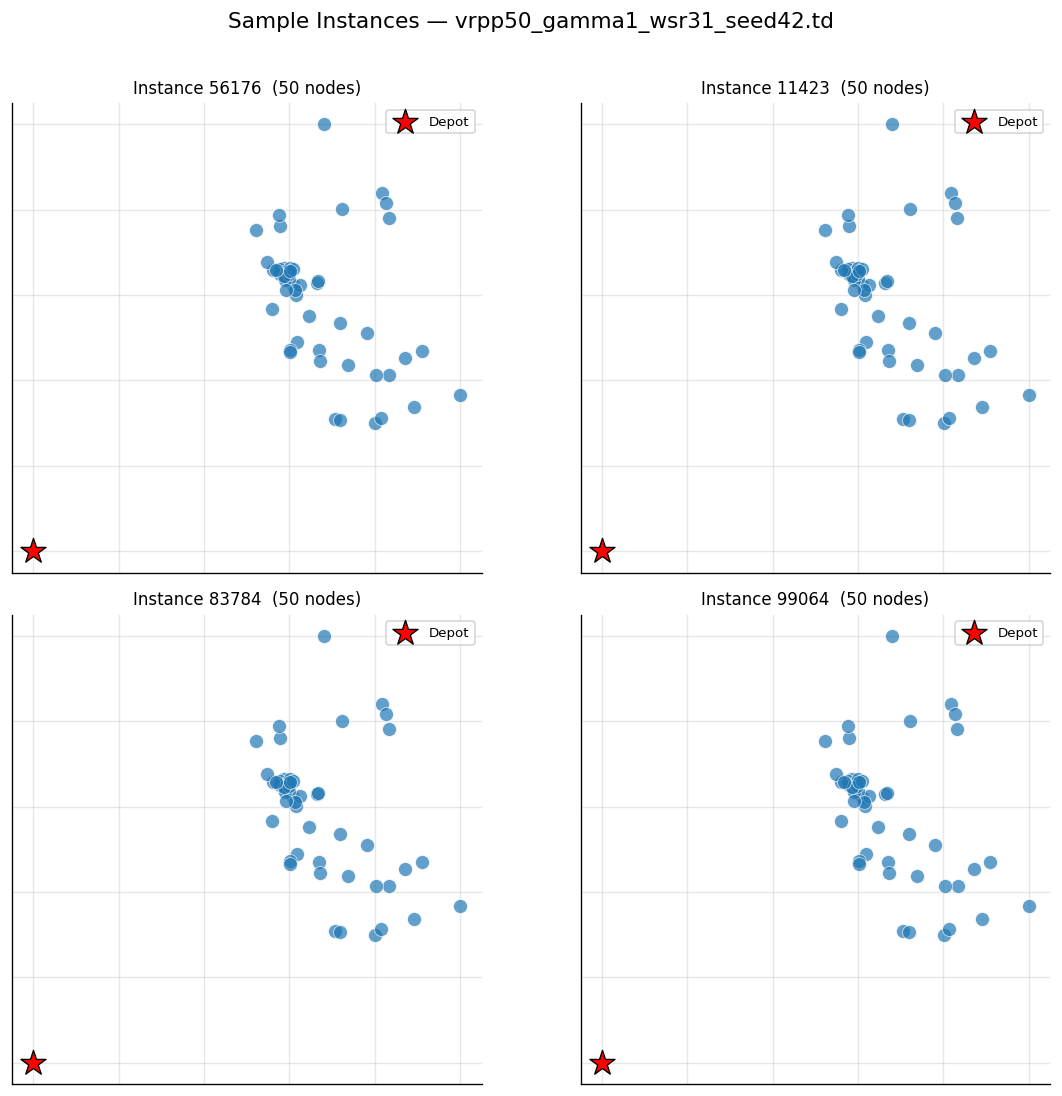

In [150]:
# ── 2 × 2 grid: 4 random instances ───────────────────────────────────────────
rng       = np.random.default_rng(SEED)
picks     = rng.choice(B, size=4, replace=False)
color_key = next(iter(NODE_SCALARS), None)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, idx in zip(axes.ravel(), picks):
    i = int(idx)
    plot_instance(
        node_xy      = locs[i],
        depot_xy     = depot[i],
        color_values = _node_scalar(NODE_SCALARS[color_key], i) if color_key else None,
        color_label  = color_key or "",
        title        = f"Instance {i}  ({N} nodes)",
        ax           = ax,
    )

plt.suptitle(
    f"Sample Instances — {os.path.basename(DATASET_PATH)}",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


### 2.2 — Location Density Across the Batch

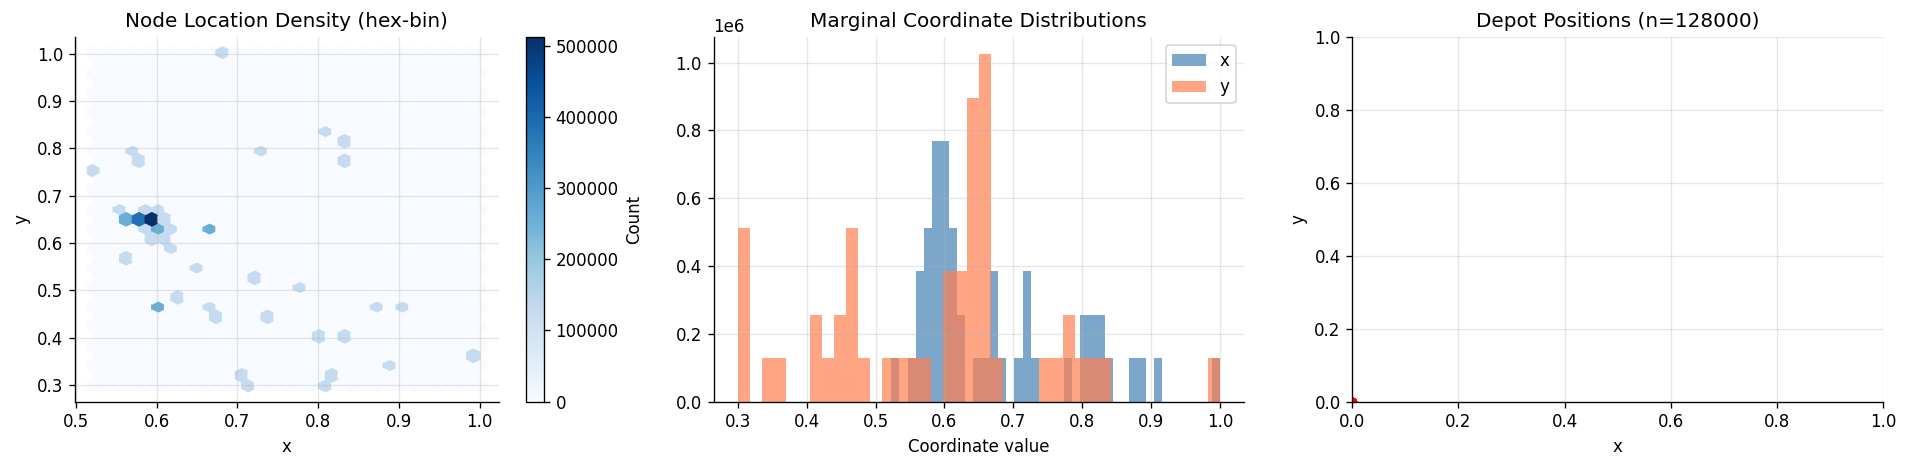

In [151]:
all_x = locs[:, :, 0].ravel()
all_y = locs[:, :, 1].ravel()
depot_x = depot[:, 0]
depot_y = depot[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2D density hex-bin
hb = axes[0].hexbin(all_x, all_y, gridsize=30, cmap="Blues")
fig.colorbar(hb, ax=axes[0], label="Count")
axes[0].set_title("Node Location Density (hex-bin)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

# Marginal distributions
axes[1].hist(all_x, bins=40, alpha=0.7, color="steelblue", label="x")
axes[1].hist(all_y, bins=40, alpha=0.7, color="coral", label="y")
axes[1].set_title("Marginal Coordinate Distributions")
axes[1].set_xlabel("Coordinate value")
axes[1].legend()

# Depot positions
axes[2].scatter(depot_x, depot_y, s=20, alpha=0.5, color="red")
axes[2].set_title(f"Depot Positions (n={B})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### 2.3 — Nearest-Neighbour Distance Analysis

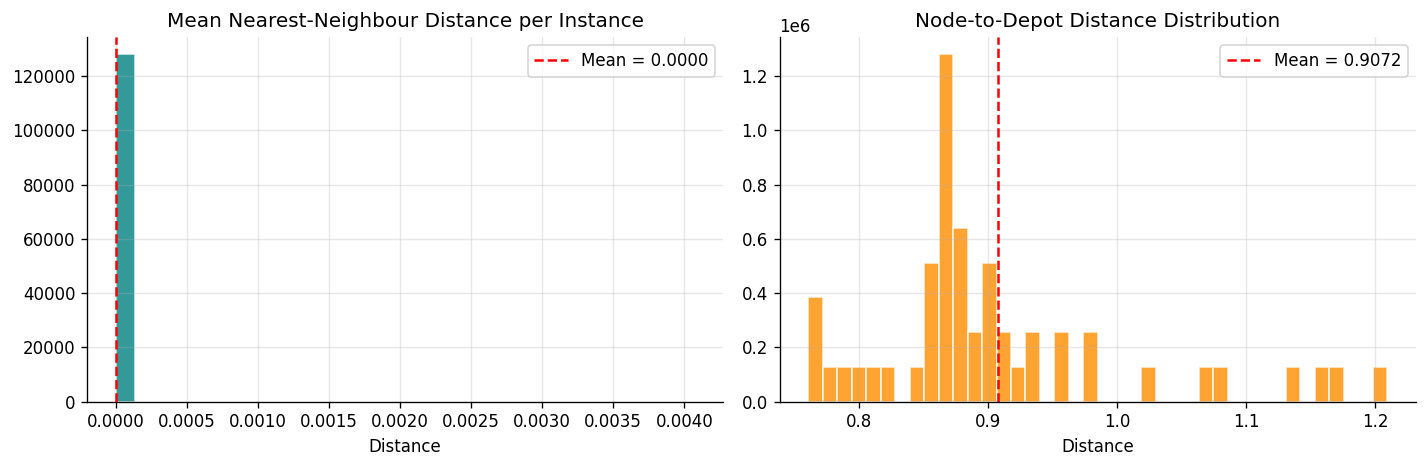

NN distance  — mean: 0.0000  std: 0.0000
Depot distance — mean: 0.9072  std: 0.1019


In [152]:
def nearest_neighbour_distances(locs: np.ndarray, k: int = 1) -> np.ndarray:
    """Return the mean k-NN distance for each instance. Shape: (B,)"""
    B, N, _ = locs.shape
    # Vectorised pairwise L2 distance: (B, N, N)
    diff = locs[:, :, None, :] - locs[:, None, :, :]   # (B, N, N, 2)
    dist = np.linalg.norm(diff, axis=-1)                # (B, N, N)
    np.fill_diagonal(dist.reshape(B, N * N).T, np.inf)  # mask self
    dist_sorted = np.sort(dist, axis=-1)[:, :, :k]      # (B, N, k)
    return dist_sorted.mean(axis=(-1, -2))               # (B,)


def depot_distances(locs: np.ndarray, depot: np.ndarray) -> np.ndarray:
    """Mean distance from each node to the depot. Shape: (B, N)"""
    return np.linalg.norm(locs - depot[:, None, :], axis=-1)  # (B, N)


nn_dist   = nearest_neighbour_distances(locs, k=1)  # (B,)
dep_dist  = depot_distances(locs, depot)             # (B, N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(nn_dist, bins=30, color="teal", alpha=0.8, edgecolor="white")
axes[0].axvline(nn_dist.mean(), color="red", linestyle="--",
                label=f"Mean = {nn_dist.mean():.4f}")
axes[0].set_title("Mean Nearest-Neighbour Distance per Instance")
axes[0].set_xlabel("Distance")
axes[0].legend()

axes[1].hist(dep_dist.ravel(), bins=40, color="darkorange", alpha=0.8, edgecolor="white")
axes[1].axvline(dep_dist.mean(), color="red", linestyle="--",
                label=f"Mean = {dep_dist.mean():.4f}")
axes[1].set_title("Node-to-Depot Distance Distribution")
axes[1].set_xlabel("Distance")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"NN distance  — mean: {nn_dist.mean():.4f}  std: {nn_dist.std():.4f}")
print(f"Depot distance — mean: {dep_dist.mean():.4f}  std: {dep_dist.std():.4f}")

---
## 3. Waste Distributions

### 3.1 — Histograms

In [153]:
n_scalars = len(NODE_SCALARS)
if n_scalars == 0:
    print("No node-level scalar tensors found in this dataset.")
else:
    fig, axes = plt.subplots(1, n_scalars, figsize=(6 * n_scalars, 4))
    axes = np.atleast_1d(axes)

    colors = ["steelblue", "darkorange", "mediumseagreen"]
    for ax, (key, arr), color in zip(axes, NODE_SCALARS.items(), colors):
        flat = arr.ravel()
        ax.hist(flat, bins=50, color=color, alpha=0.85, edgecolor="white")
        ax.axvline(flat.mean(), color="red",   linestyle="--", label=f"Mean={flat.mean():.3f}")
        ax.axvline(np.median(flat), color="black", linestyle=":", label=f"Median={np.median(flat):.3f}")
        ax.set_title(f"`{key}` distribution")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    plt.suptitle("Node-Level Scalar Distributions (all instances)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

No node-level scalar tensors found in this dataset.


### 3.2 — Box Plots per Instance (sample)

In [154]:
SAMPLE_N = min(30, B)  # show at most 30 instance boxes to keep the plot readable
sample_idx_box = np.random.choice(B, SAMPLE_N, replace=False)
sample_idx_box.sort()

for key, arr in NODE_SCALARS.items():
    data_sample = [arr[i] for i in sample_idx_box]  # list of length SAMPLE_N

    fig, ax = plt.subplots(figsize=(max(8, SAMPLE_N * 0.35), 4))
    bp = ax.boxplot(data_sample, patch_artist=True,
                    boxprops=dict(facecolor="lightsteelblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=1.5),
                    flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_xticks(range(1, SAMPLE_N + 1))
    ax.set_xticklabels(sample_idx_box, rotation=90, fontsize=7)
    ax.set_title(f"`{key}` — box plots for {SAMPLE_N} instances")
    ax.set_xlabel("Instance index")
    ax.set_ylabel(key)
    plt.tight_layout()
    plt.show()

### 3.3 — Probability Density Function (KDE)

In [155]:

from scipy.stats import gaussian_kde

if not NODE_SCALARS:
    print("No node-level scalar tensors found.")
else:
    n_scalars = len(NODE_SCALARS)
    fig, axes = plt.subplots(1, n_scalars, figsize=(6 * n_scalars, 4))
    axes = np.atleast_1d(axes)

    colors = ["steelblue", "darkorange", "mediumseagreen"]
    for ax, (key, arr), color in zip(axes, NODE_SCALARS.items(), colors):
        flat    = arr.ravel()
        x_range = np.linspace(float(flat.min()), float(flat.max()), 400)

        # Kernel Density Estimate (Scott's rule bandwidth)
        kde      = gaussian_kde(flat, bw_method="scott")
        pdf_vals = kde(x_range)

        # Normalised histogram as reference
        ax.hist(flat, bins=50, density=True,
                color=color, alpha=0.35, edgecolor="white", label="Histogram (density)")

        # KDE curve
        ax.plot(x_range, pdf_vals, color=color, linewidth=2.5, label="KDE")
        ax.fill_between(x_range, pdf_vals, alpha=0.12, color=color)

        # Reference lines
        ax.axvline(flat.mean(),     color="red",   linestyle="--", linewidth=1.5,
                   label=f"Mean   = {flat.mean():.3f}")
        ax.axvline(np.median(flat), color="black", linestyle=":",  linewidth=1.5,
                   label=f"Median = {np.median(flat):.3f}")

        ax.set_title(f"`{key}` — PDF  (bw = Scott's rule)")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

    plt.suptitle("Probability Density Functions — Node Scalars (all instances)",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


No node-level scalar tensors found.


### 3.4 — Empirical CDF

In [156]:
if NODE_SCALARS:
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ["steelblue", "darkorange", "mediumseagreen"]
    for (key, arr), color in zip(NODE_SCALARS.items(), colors):
        flat  = np.sort(arr.ravel())
        cdf_y = np.arange(1, len(flat) + 1) / len(flat)
        ax.plot(flat, cdf_y, label=key, color=color, linewidth=2)

    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative probability")
    ax.set_title("Empirical CDF — Node Scalars")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3.5 — Instance-Level Scalar Constants

In [157]:

if INST_SCALARS:
    rows = []
    for key, arr in INST_SCALARS.items():
        flat = arr.ravel().astype(float)
        rows.append({
            "Key"    : key,
            "Min"    : flat.min(),
            "Max"    : flat.max(),
            "Mean"   : flat.mean(),
            "Std"    : flat.std(),
            "Unique" : len(np.unique(flat)),
        })
    display(pd.DataFrame(rows).set_index("Key").map(
        lambda v: f"{v:.4f}" if isinstance(v, float) else v
    ))
else:
    print("No instance-level scalars found.")


,Min,Max,Mean,Std,Unique
Key,,,,,
capacity,100.0000,100.0000,100.0000,0.0000,1
max_waste,1.0000,1.0000,1.0000,0.0000,1


### 3.6 — Per-Bin Waste Histograms

In [158]:

# Resolve waste from NODE_SCALARS (already collapsed to (B, N) by cell-07)
_WASTE_KEY = next((k for k in ("waste") if k in NODE_SCALARS), None)

if _WASTE_KEY is None:
    print("No waste key found — skipping.")
else:
    waste_bn    = NODE_SCALARS[_WASTE_KEY]      # (B, N)
    node_means  = waste_bn.mean(axis=0)         # (N,)
    node_stds   = waste_bn.std(axis=0)          # (N,)
    node_counts = np.full(N, B)
    x           = np.arange(N)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Left: population frequency histogram ──────────────────────────────────
    ax = axes[0]
    counts, bin_edges, patches = ax.hist(
        waste_bn.ravel(), bins=40,
        color="steelblue", edgecolor="white", alpha=0.85,
    )
    ax.axvline(waste_bn.mean(),     color="red",   linestyle="--", linewidth=1.5,
               label=f"Mean   = {waste_bn.mean():.3f}")
    ax.axvline(np.median(waste_bn), color="black", linestyle=":",  linewidth=1.5,
               label=f"Median = {np.median(waste_bn):.3f}")
    ax.set_title(f"`{_WASTE_KEY}` — population histogram  (B={B}, N={N})")
    ax.set_xlabel("Waste level")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

    # ── Right: per-bin mean bar chart with ± 1 std band ───────────────────────
    ax = axes[1]
    ax.bar(x, node_means, color="steelblue", alpha=0.85, zorder=2, label="Mean")
    ax.fill_between(
        x,
        node_means - node_stds,
        node_means + node_stds,
        alpha=0.30, color="steelblue", zorder=1, label="± 1 std",
    )
    ax.set_title(f"`{_WASTE_KEY}` — mean per bin  (± 1 std,  {B} instances)")
    ax.set_xlabel("Bin index")
    ax.set_ylabel("Waste level")
    tick_step = max(1, N // 10)
    ax.set_xticks(x[::tick_step])
    ax.legend(fontsize=9)

    plt.suptitle(
        f"Bin Waste Histograms — {os.path.basename(DATASET_PATH)}",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

    print(f"Global  — mean: {waste_bn.mean():.4f}  std: {waste_bn.std():.4f}  "
          f"min: {waste_bn.min():.4f}  max: {waste_bn.max():.4f}")
    print(f"Per-bin mean range: [{node_means.min():.4f}, {node_means.max():.4f}]")
    print(f"Per-bin std  range: [{node_stds.min():.4f}, {node_stds.max():.4f}]")


No waste key found — skipping.


### 3.7 — Per-Bin Box & Whisker Plots

In [159]:

if _WASTE_KEY is None:
    print("No waste key found — skipping.")
else:
    waste_bn = NODE_SCALARS[_WASTE_KEY]   # (B, N)

    # Cap boxes for readability; stride through bin indices if N is large
    MAX_BOXES = 60
    step        = max(1, N // MAX_BOXES)
    bin_indices = list(range(0, N, step))
    data        = [waste_bn[:, j] for j in bin_indices]

    fig_w  = max(10, len(bin_indices) * 0.45)
    fig, ax = plt.subplots(figsize=(fig_w, 5))

    bp = ax.boxplot(
        data,
        patch_artist=True,
        boxprops    = dict(facecolor="lightsteelblue", alpha=0.85),
        medianprops = dict(color="red",   linewidth=2.0),
        meanprops   = dict(marker="D",    markerfacecolor="orange",
                           markeredgecolor="darkorange", markersize=4),
        flierprops  = dict(marker=".",    markersize=1.5, alpha=0.15,
                           markerfacecolor="slategray"),
        whiskerprops= dict(linewidth=1.0, linestyle="--"),
        capprops    = dict(linewidth=1.2),
        showmeans   = True,
    )

    ax.set_xticks(range(1, len(bin_indices) + 1))
    ax.set_xticklabels(
        bin_indices,
        rotation=90 if len(bin_indices) > 20 else 0,
        fontsize=8,
    )
    ax.set_xlabel("Bin index")
    ax.set_ylabel("Waste level")

    stride_note = f", every {step} bins" if step > 1 else ""
    ax.set_title(
        f"`{_WASTE_KEY}` — box & whisker per bin  "
        f"(n = {B:,} instances{stride_note})"
    )

    # Legend proxies
    from matplotlib.patches import Patch
    from matplotlib.lines   import Line2D
    legend_handles = [
        Patch(facecolor="lightsteelblue", alpha=0.85, label="IQR (box)"),
        Line2D([0], [0], color="red",    linewidth=2,  label="Median"),
        Line2D([0], [0], color="orange", linewidth=0,
               marker="D", markerfacecolor="orange", markersize=5, label="Mean"),
        Line2D([0], [0], color="gray",   linewidth=1,
               linestyle="--", label="1.5 × IQR (whiskers)"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right", framealpha=0.85)

    plt.tight_layout()
    plt.show()

    # Summary stats table
    q1   = np.percentile(waste_bn, 25, axis=0)   # (N,)
    q3   = np.percentile(waste_bn, 75, axis=0)   # (N,)
    iqr  = q3 - q1
    summary = pd.DataFrame({
        "Mean"  : node_means.round(4),
        "Std"   : node_stds.round(4),
        "Q1"    : q1.round(4),
        "Median": np.median(waste_bn, axis=0).round(4),
        "Q3"    : q3.round(4),
        "IQR"   : iqr.round(4),
        "Min"   : waste_bn.min(axis=0).round(4),
        "Max"   : waste_bn.max(axis=0).round(4),
    }, index=pd.Index(range(N), name="Bin"))
    print(f"\nPer-bin summary (first 10 / {N} bins shown):")
    display(summary.head(10))


No waste key found — skipping.


---
## 4. Cross-Tensor Correlation

### 4.1 — Distance-to-Depot vs Node Scalar

In [160]:
dep_dist_flat = dep_dist.ravel()  # (B*N,) computed earlier

for key, arr in NODE_SCALARS.items():
    flat   = arr.ravel()
    MAX_PTS = 10_000
    idx = np.random.choice(len(flat), min(MAX_PTS, len(flat)), replace=False)
    corr = np.corrcoef(dep_dist_flat, flat)[0, 1]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hexbin(dep_dist_flat[idx], flat[idx], gridsize=25, cmap="YlOrRd")
    ax.set_title(f"Distance-to-Depot vs `{key}`  (r = {corr:.3f})")
    ax.set_xlabel("Distance to depot")
    ax.set_ylabel(key)
    plt.tight_layout()
    plt.show()

### 4.2 — Pairwise Correlation Matrix (node scalars)

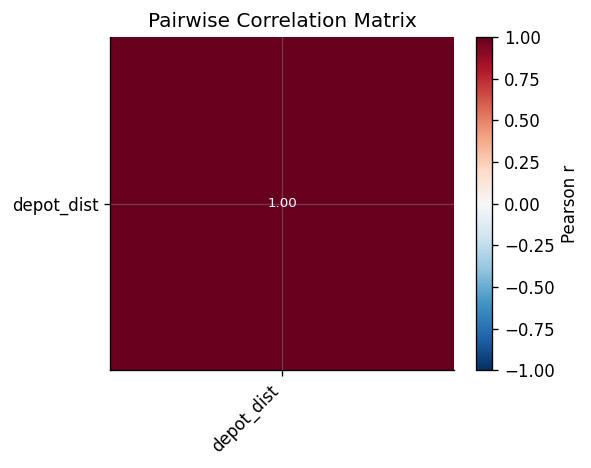

In [161]:
feature_dict = {**{k: v.ravel() for k, v in NODE_SCALARS.items()},
                "depot_dist": dep_dist_flat}
feature_df = pd.DataFrame(feature_dict)

corr_matrix = feature_df.corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
plt.colorbar(im, ax=ax, label="Pearson r")
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black")
ax.set_title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

---
## 5. Batch-Level Statistics

Compute per-instance aggregates to see how much variability exists *across* instances (as opposed to variability *within* a single instance).

### 5.1 — Per-Instance Mean and Std

In [162]:
for key, arr in NODE_SCALARS.items():
    inst_mean = arr.mean(axis=1)  # (B,)
    inst_std  = arr.std(axis=1)   # (B,)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

    axes[0].hist(inst_mean, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[0].set_title(f"`{key}` — per-instance mean")
    axes[0].set_xlabel("Instance mean")

    axes[1].hist(inst_std, bins=30, color="coral", edgecolor="white", alpha=0.85)
    axes[1].set_title(f"`{key}` — per-instance std")
    axes[1].set_xlabel("Instance std")

    plt.suptitle(f"Across-batch variability for `{key}`", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"{key}: mean-of-means={inst_mean.mean():.4f}  std-of-means={inst_mean.std():.4f}")

### 5.2 — Mean vs Std per Instance (scatter)

In [163]:
if NODE_SCALARS:
    key, arr = next(iter(NODE_SCALARS.items()))
    inst_mean = arr.mean(axis=1)
    inst_std  = arr.std(axis=1)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(inst_mean, inst_std, s=15, alpha=0.5, color="teal")
    ax.set_xlabel(f"Instance mean({key})")
    ax.set_ylabel(f"Instance std({key})")
    ax.set_title(f"Mean vs Std across instances — `{key}`")
    plt.tight_layout()
    plt.show()

---
## 6. Multi-Dataset Comparison

Compare datasets of **different problem sizes** or **different distributions** side-by-side.

### 6.1 — Across Problem Sizes

In [164]:
# ── Paths to compare ─────────────────────────────────────────────────────────
# Edit this list to include the datasets you want to compare.
GRAPH_SIZES = [20, 50, 100]
COMPARE_PATHS = [
    os.path.join(PROJECT_ROOT, "data", "datasets", PROBLEM_NAME, 
        f"{PROBLEM_NAME}{GRAPH_SIZES[0]}_{DATA_DISTRIBUTION}_{DATASET_NAME}{N_DAYS}_seed{SEED}.td"),
    os.path.join(PROJECT_ROOT, "data", "datasets", PROBLEM_NAME, 
        f"{PROBLEM_NAME}{GRAPH_SIZES[1]}_{DATA_DISTRIBUTION}_{DATASET_NAME}{N_DAYS}_seed{SEED}.td"),
    os.path.join(PROJECT_ROOT, "data", "datasets", PROBLEM_NAME, 
        f"{PROBLEM_NAME}{GRAPH_SIZES[2]}_{DATA_DISTRIBUTION}_{DATASET_NAME}{N_DAYS}_seed{SEED}.td"),
]
COMPARE_PATHS = [p for p in COMPARE_PATHS if os.path.exists(p)]

datasets = {}
for path in COMPARE_PATHS:
    label = os.path.basename(path).replace(".td", "")
    datasets[label] = torch.load(path, map_location="cpu", weights_only=False)
    print(f"Loaded {label}: batch={datasets[label].batch_size[0]}, "
          f"nodes={datasets[label]['locs'].shape[1]}")

Loaded vrpp20_gamma1_wsr31_seed42: batch=128000, nodes=20
Loaded vrpp50_gamma1_wsr31_seed42: batch=128000, nodes=50


Loaded vrpp100_gamma1_wsr31_seed42: batch=128000, nodes=100


In [165]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, ds in datasets.items():
    row = {"Dataset": label,
           "Batch": ds.batch_size[0],
           "Nodes": ds["locs"].shape[1]}
    for key in ("waste"):
        if key in ds.keys():
            arr = ds[key].numpy().ravel()
            row[f"{key}_mean"] = f"{arr.mean():.4f}"
            row[f"{key}_std"]  = f"{arr.std():.4f}"
    rows.append(row)

display(pd.DataFrame(rows).set_index("Dataset"))

,Batch,Nodes
Dataset,,
vrpp20_gamma1_wsr31_seed42,128000,20
vrpp50_gamma1_wsr31_seed42,128000,50
vrpp100_gamma1_wsr31_seed42,128000,100


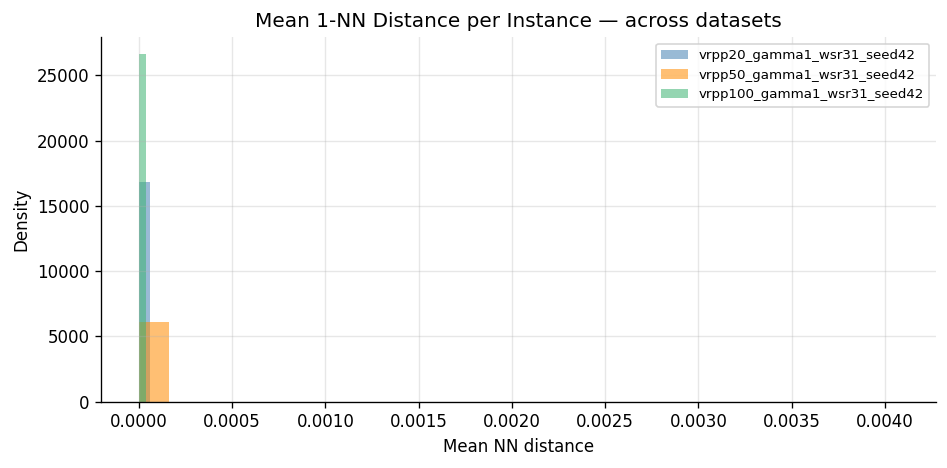

In [167]:
# ── Nearest-neighbour distance across problem sizes ───────────────────────────
if datasets:
    fig, ax = plt.subplots(figsize=(8, 4))
    for (label, ds), color in zip(datasets.items(), colors):
        l = ds["locs"].numpy()
        nn = nearest_neighbour_distances(l, k=1)
        ax.hist(nn, bins=25, alpha=0.55, label=label, color=color, density=True)

    ax.set_title("Mean 1-NN Distance per Instance — across datasets")
    ax.set_xlabel("Mean NN distance")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### 6.2 — Waste Comparison Across Data Distributions

Compare how the **waste fill-level distribution** changes between `gamma1`, `gamma3`, and `emp` for a **fixed graph size**.  
Set `COMPARE_GRAPH_SIZE` in the first cell to switch between 20 / 50 / 100 / 170.

| Plot | What it reveals |
|------|-----------------|
| Histogram + KDE | Mode, shape, and density of each distribution |
| Empirical CDF | Stochastic dominance and tail behaviour |
| Violin plots | Full distributional spread side-by-side |
| Per-bin line plots | Whether waste patterns differ across bin indices |
| Heatmap | Distribution × bin-index mean waste at a glance |

In [ ]:

# ── Configure: fix graph size, iterate distributions ─────────────────────────
COMPARE_GRAPH_SIZE = 50            # change to 20, 100, or 170 as needed
DISTRIBUTIONS      = ["gamma1", "gamma3", "emp"]
DIST_COLORS        = ["steelblue", "darkorange", "mediumseagreen"]
DIST_LABELS        = {
    "gamma1": "Gamma-1  (γ=1)",
    "gamma3": "Gamma-3  (γ=3)",
    "emp"   : "Empirical",
}

dist_waste: dict = {}   # dist name → np.ndarray  (B, N)

for dist in DISTRIBUTIONS:
    path = os.path.join(
        PROJECT_ROOT, "data", "datasets", PROBLEM_NAME,
        f"{PROBLEM_NAME}{COMPARE_GRAPH_SIZE}_{dist}_{DATASET_NAME}{N_DAYS}_seed{SEED}.td",
    )
    if not os.path.exists(path):
        print(f"  {dist}: not found — {path}")
        continue
    ds  = torch.load(path, map_location="cpu", weights_only=False)
    arr = ds["waste"].numpy()
    if arr.ndim == 3:              # (B, T, N) → (B, N)
        arr = arr.mean(axis=1)
    dist_waste[dist] = arr
    flat = arr.ravel()
    print(
        f"  {dist:8s}: shape={arr.shape}  "
        f"mean={flat.mean():.4f}  std={flat.std():.4f}  "
        f"skew={float(pd.Series(flat).skew()):+.3f}"
    )

print(f"\n{len(dist_waste)} distributions loaded  (N={COMPARE_GRAPH_SIZE})")

# ── Summary statistics table ───────────────────────────────────────────────────
_stat_rows = []
for dist, arr in dist_waste.items():
    flat = arr.ravel()
    _stat_rows.append({
        "Distribution": DIST_LABELS.get(dist, dist),
        "Min"     : round(float(flat.min()),                    4),
        "Q1"      : round(float(np.percentile(flat, 25)),       4),
        "Median"  : round(float(np.median(flat)),               4),
        "Mean"    : round(float(flat.mean()),                   4),
        "Q3"      : round(float(np.percentile(flat, 75)),       4),
        "Max"     : round(float(flat.max()),                    4),
        "Std"     : round(float(flat.std()),                    4),
        "Skewness": round(float(pd.Series(flat).skew()),        3),
        "Kurtosis": round(float(pd.Series(flat).kurtosis()),    3),
    })

display(pd.DataFrame(_stat_rows).set_index("Distribution"))


In [ ]:

from scipy.stats import gaussian_kde as _gkde

if not dist_waste:
    print("Run the loading cell above first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for (dist, arr), color in zip(dist_waste.items(), DIST_COLORS):
        label = DIST_LABELS.get(dist, dist)
        flat  = arr.ravel()
        x_rng = np.linspace(float(flat.min()), float(flat.max()), 500)
        kde_v = _gkde(flat, bw_method="scott")(x_rng)

        # Overlaid histogram
        axes[0].hist(flat, bins=60, density=True, alpha=0.40,
                     color=color, edgecolor="none", label=label)

        # KDE curve + fill + mean reference line
        axes[1].plot(x_rng, kde_v, color=color, linewidth=2.5, label=label)
        axes[1].fill_between(x_rng, kde_v, alpha=0.12, color=color)
        axes[1].axvline(flat.mean(), color=color, linestyle="--",
                        linewidth=1.0, alpha=0.8)

    for ax, title in zip(axes, [
        f"Waste histograms — N={COMPARE_GRAPH_SIZE}",
        f"KDE curves — N={COMPARE_GRAPH_SIZE}  (dashed = mean)",
    ]):
        ax.set_xlabel("Waste level")
        ax.set_ylabel("Density")
        ax.set_title(title)
        ax.legend(fontsize=9)

    plt.suptitle(
        f"Waste Distributions — Across Data Distributions  (N={COMPARE_GRAPH_SIZE})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()


In [ ]:

if not dist_waste:
    print("Run the loading cell above first.")
else:
    _MAX_PTS  = 100_000   # subsample for CDF smoothness
    _VLN_PTS  = 50_000    # subsample for violin speed

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    vln_data, vln_labels = [], []

    for (dist, arr), color in zip(dist_waste.items(), DIST_COLORS):
        label = DIST_LABELS.get(dist, dist)
        flat  = arr.ravel()

        # ── Left: Empirical CDF (subsampled) ──────────────────────────────────
        sub = np.sort(np.random.choice(flat, min(_MAX_PTS, len(flat)), replace=False))
        axes[0].plot(sub, np.linspace(0, 1, len(sub)),
                     color=color, linewidth=2.0, label=label)

        # Collect violin data (subsampled)
        vln_data.append(np.random.choice(flat, min(_VLN_PTS, len(flat)), replace=False))
        vln_labels.append(label)

    axes[0].set_title(f"Empirical CDF — waste  (N={COMPARE_GRAPH_SIZE})")
    axes[0].set_xlabel("Waste level")
    axes[0].set_ylabel("Cumulative probability")
    axes[0].legend(fontsize=9)

    # ── Right: Violin plot ────────────────────────────────────────────────────
    parts = axes[1].violinplot(
        vln_data,
        positions=range(len(vln_data)),
        showmedians=True,
        showextrema=True,
    )
    for pc, color in zip(parts["bodies"], DIST_COLORS):
        pc.set_facecolor(color)
        pc.set_alpha(0.70)
    parts["cmedians"].set_color("red")
    parts["cmedians"].set_linewidth(2.0)
    for k in ("cmins", "cmaxes", "cbars"):
        if k in parts:
            parts[k].set_linewidth(1.0)

    axes[1].set_xticks(range(len(vln_labels)))
    axes[1].set_xticklabels(vln_labels, fontsize=9)
    axes[1].set_title(f"Violin plots — waste  (N={COMPARE_GRAPH_SIZE})")
    axes[1].set_xlabel("Distribution")
    axes[1].set_ylabel("Waste level")

    plt.suptitle(
        f"CDF & Violin Comparison — Across Distributions  (N={COMPARE_GRAPH_SIZE})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()


In [ ]:

if not dist_waste:
    print("Run the loading cell above first.")
else:
    _n  = COMPARE_GRAPH_SIZE
    _x  = np.arange(_n)

    # ── Per-bin mean (line + ±1 std band) and per-bin std ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for (dist, arr), color in zip(dist_waste.items(), DIST_COLORS):
        label    = DIST_LABELS.get(dist, dist)
        bin_mean = arr.mean(axis=0)   # (N,)
        bin_std  = arr.std(axis=0)    # (N,)
        axes[0].plot(_x, bin_mean, color=color, linewidth=2.0, label=label)
        axes[0].fill_between(_x, bin_mean - bin_std, bin_mean + bin_std,
                             alpha=0.15, color=color)
        axes[1].plot(_x, bin_std, color=color, linewidth=2.0, label=label)

    axes[0].set_title(f"Per-bin mean waste  (± 1 std,  N={_n})")
    axes[0].set_xlabel("Bin index"); axes[0].set_ylabel("Mean waste level")
    axes[0].legend(fontsize=9)

    axes[1].set_title(f"Per-bin waste std  (N={_n})")
    axes[1].set_xlabel("Bin index"); axes[1].set_ylabel("Waste std")
    axes[1].legend(fontsize=9)

    plt.suptitle(
        f"Per-Bin Waste Statistics — N={COMPARE_GRAPH_SIZE}",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # ── Heatmap: distribution × bin index ─────────────────────────────────────
    heat   = np.vstack([arr.mean(axis=0) for arr in dist_waste.values()])  # (D, N)
    hlbls  = [DIST_LABELS.get(d, d) for d in dist_waste]
    step   = max(1, _n // 10)

    fig2, ax = plt.subplots(figsize=(max(10, _n * 0.25), 2.5))
    im = ax.imshow(heat, aspect="auto", cmap="YlOrRd",
                   vmin=0.0, vmax=float(heat.max()))
    plt.colorbar(im, ax=ax, label="Mean waste level", pad=0.02)
    ax.set_yticks(range(len(hlbls)))
    ax.set_yticklabels(hlbls, fontsize=9)
    ax.set_xticks(range(0, _n, step))
    ax.set_xticklabels(range(0, _n, step), fontsize=8)
    ax.set_xlabel("Bin index")
    ax.set_title(
        f"Mean Waste Heatmap — Distribution × Bin  (N={COMPARE_GRAPH_SIZE})"
    )
    plt.tight_layout()
    plt.show()


---
## 7. PyTorch DataLoader Integration

Shows how to wrap a `TensorDict` in a `Dataset` and iterate over mini-batches — the typical first step before feeding data to a model.

In [ ]:
from logic.src.data.datasets import TensorDictDataset
from logic.src.utils.data.td_utils import tensordict_collate_fn

BATCH_SIZE_DL = 32

dataset = TensorDictDataset(td)
loader  = DataLoader(
    dataset,
    batch_size=BATCH_SIZE_DL,
    shuffle=True,
    collate_fn=tensordict_collate_fn,
)

print(f"Dataset size    : {len(dataset)}")
print(f"Batch size      : {BATCH_SIZE_DL}")
print(f"Batches per epoch: {len(loader)}")

In [ ]:
# Inspect a single batch
batch = next(iter(loader))

print("Mini-batch tensors:")
for key in batch.keys():
    t = batch[key]
    print(f"  {key:15s} shape={tuple(t.shape)}  dtype={t.dtype}")

In [ ]:
# Measure throughput over one epoch
import time

start = time.perf_counter()
total_instances = 0
for batch in loader:
    total_instances += batch.batch_size[0] if hasattr(batch, "batch_size") else BATCH_SIZE_DL
elapsed = time.perf_counter() - start

print(f"One epoch — {total_instances} instances in {elapsed:.2f}s  "
      f"({total_instances / elapsed:.0f} instances/s)")

---
## 8. Quick Report — Printable Summary

In [ ]:
def print_report(td: TensorDict, path: str) -> None:
    """Print a concise one-page summary of a TensorDict dataset."""
    b   = td.batch_size[0]
    loc = td["locs"]
    n   = loc.shape[1]
    size_mb = os.path.getsize(path) / 1e6 if os.path.exists(path) else 0

    print("=" * 60)
    print(f"  TensorDict Dataset Report")
    print(f"  File    : {os.path.basename(path)}")
    print(f"  Size    : {size_mb:.1f} MB")
    print("=" * 60)
    print(f"  Instances  : {b}")
    print(f"  Nodes/inst : {n}")
    print(f"  Keys       : {', '.join(td.keys())}")
    print()
    print(f"  {'Key':<14} {'Shape':<20} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
    print(f"  {'-'*68}")
    for key in td.keys():
        t = td[key].float()
        print(f"  {key:<14} {str(tuple(t.shape)):<20} "
              f"{t.min().item():>8.4f} {t.max().item():>8.4f} "
              f"{t.mean().item():>8.4f} {t.std().item():>8.4f}")
    print("=" * 60)


print_report(td, DATASET_PATH)

---
## Summary

This notebook demonstrated a complete analysis workflow for a WSmart+ Route TensorDict dataset:

| Section | What you learned |
|---------|------------------|
| **1 — Loading** | `torch.load()` with `weights_only=False`; key inventory with shapes / dtypes / memory |
| **2 — Spatial** | Node density maps, marginal coordinate distributions, depot positions, NN distances |
| **3 — Scalars** | Histograms, box plots per instance, empirical CDFs for waste |
| **4 — Batch stats** | Per-instance mean / std distributions, spatial waste heatmap |
| **5 — Comparison** | Side-by-side analysis of multiple datasets (different sizes / distributions) |
| **6 — DataLoader** | `TensorDictDataset` + `DataLoader` setup, batch inspection, epoch throughput |
| **7 — Report** | Concise printable summary of any `.td` file |

### Next Steps

- **Train a model** on this data → see [`tutorials/04_training_with_lightning.ipynb`](tutorials/04_training_with_lightning.ipynb)
- **Evaluate a policy** → see [`tutorials/05_evaluation_and_decoding.ipynb`](tutorials/05_evaluation_and_decoding.ipynb)
- **Run a simulation** → see [`tutorials/06_simulation_testing.ipynb`](tutorials/06_simulation_testing.ipynb)